# Clasificación de Residuos — Modelo D4: EfficientNetV2B0 Minimal

---

## Contexto del Experimento

Este notebook forma parte de una **serie de experimentos de Transfer Learning** que aplica la técnica de la tijera: partimos del modelo más complejo (D0) y reducimos progresivamente la cabeza para encontrar el punto óptimo de simplicidad sin perder rendimiento.

### Estrategia Experimental

- **Punto de partida**: D3 (GAP → Dense(6) → Dropout(0.3)) — F1=0.8402
- **Enfoque**: ¿Eliminar completamente la Dense intermedia y aplicar Dropout directo sobre las features del backbone mejora respecto a D3?
- **Observable**: Impacto de quitar la capa densa y dejar solo GAP → Dropout → Softmax

Cada modelo se implementa en un archivo independiente dentro de la carpeta `models/` del proyecto.

---

## Arquitectura del Modelo D4

### Descripción

**EfficientNetV2B0 Minimal** es el extremo más simple de la serie descendente: elimina completamente la capa densa intermedia y aplica Dropout directamente sobre las 1280 features del GAP antes del clasificador final. El backbone EfficientNetV2B0 está completamente descongelado desde el inicio, con LR bajo para preservar los pesos preentrenados.

### Posición en la Serie Descendente

| Componente | D3 (Anterior) | D4 (Este modelo) |
|------------|--------------|-----------------|
| **Backbone** | EfficientNetV2B0 descongelado | EfficientNetV2B0 descongelado |
| **Cabeza** | GAP → Dense(6) → Dropout(0.3) → softmax | GAP → Dropout(0.3) → softmax |
| **Parámetros** | 5,927,040 | 5,926,998 |

**Hipótesis**: El Dropout sobre 1280 features tiene suficiente redundancia para no dañar el aprendizaje, a diferencia de D3 donde caía sobre solo 6 neuronas. La clasificación lineal directa sobre las features del backbone puede ser suficiente.

---

## Resumen resultado final rendimiento en el conjunto de test

| Modelo | Parámetros | Accuracy | Precision | Recall | F1-Score |
|--------|----------:|--------:|----------:|-------:|--------:|
| A1 (SimpleCNN) | 210 | 0.4921 | 0.4257 | 0.4326 | 0.4150 |
| A2 (CNN Small) | 1,094 | 0.6100 | 0.6600 | 0.5600 | 0.5700 |
| A3 (CNN Medium) | 19,782 | 0.7263 | 0.7114 | 0.6884 | 0.6973 |
| A4 (CNN Large) | 94,918 | 0.7816 | 0.7643 | 0.7741 | 0.7578 |
| D0 (EffNet Full) | 6,253,910 | 0.9316 | 0.9199 | 0.9121 | 0.9139 |
| D1 (EffNet Top) | 6,248,790 | 0.9132 | 0.8815 | 0.9026 | 0.8874 |
| D2 (EffNet Head) | 6,084,054 | 0.9079 | 0.8797 | 0.9040 | 0.8871 |
| D3 (EffNet GAP) | 5,927,040 | 0.9132 | 0.8861 | 0.8344 | 0.8402 |
| **D4 (EffNet Minimal)** | **5,926,998** | **0.9211** | **0.8995** | **0.9172** | **0.9054** |

### Rendimiento por clase (Test)

| Clase | Precision | Recall | F1-Score | Support |
|-------|----------:|-------:|---------:|--------:|
| cardboard | 0.90 | 1.00 | 0.94 | 60 |
| glass | 0.97 | 0.80 | 0.88 | 76 |
| metal | 0.90 | 1.00 | 0.95 | 62 |
| paper | 0.97 | 0.93 | 0.95 | 89 |
| plastic | 0.93 | 0.92 | 0.92 | 73 |
| trash | 0.74 | 0.85 | 0.79 | 20 |

**Nota**: D4 sorprende siendo el segundo mejor modelo de toda la serie (F1=0.9054), solo por detrás de D0 (0.9139), y superando a D1, D2 y D3 a pesar de tener la cabeza más simple. La clave está en que el Dropout sobre 1280 features es inofensivo, mientras que en D3 sobre 6 neuronas era devastador. La clase `trash` recupera F1=0.79, el mejor resultado de la serie exceptuando D0. Esto confirma que para este backbone, la cabeza óptima es o muy compleja con BN (D0) o directamente mínima (D4) — las opciones intermedias D1-D3 quedan en tierra de nadie.

---

## Implementación

A continuación se entrena y evalúa el modelo D4 usando el pipeline estándar del proyecto.

---
## 0. Configuración del entorno (Colab)


In [1]:
# Celda 1 — Limpieza y configuración GPU
import gc
import keras
keras.backend.clear_session()
gc.collect()

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"Memory growth activado en {len(gpus)} GPU(s)")

print(tf.__version__)

2026-03-29 11:15:48.946218: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-29 11:15:48.973024: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-29 11:15:49.605224: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Memory growth activado en 1 GPU(s)
2.20.0


In [2]:
# ========================================
# 1. IMPORTS Y CONFIGURACION
# ========================================

import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import keras

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Agregar ruta del proyecto al path (carpeta padre de notebooks)
sys.path.insert(0, '..')

# Importar funciones de utilidad
from src.utils import initialize_project

---
## 1. Carga de datos


In [3]:
# ========================================
# 2. CARGA DE DATOS Y CONFIGURACION
# ========================================

X_train, y_train, X_val, y_val, X_test, y_test, class_names = initialize_project()

Ejecutando en local

Cargando datos desde: /home/gosacar/Profundo/notebooks/../data/processed/trashnet_224x224.npz
  X.shape: (2527, 224, 224, 3)
  y.shape: (2527,)
  Clases: cardboard, glass, metal, paper, plastic, trash

División estratificada (seed=44):
  Train: 1768 imágenes (70%)
  Val:   379 imágenes (15%)
  Test:  380 imágenes (15%)


In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

SEED       = 44   # ← tu semilla
BATCH_SIZE = 32
NUM_CLASSES = len(class_names)

augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.05, 0.05),
], name='augmentation')

def make_dataset(X, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(len(X), seed=SEED)
        ds = ds.map(lambda x, y: (augmentation(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

ds_train = make_dataset(X_train, y_train, training=True)
ds_val   = make_dataset(X_val,   y_val)
ds_test  = make_dataset(X_test,  y_test)

print('Datasets listos')

I0000 00:00:1774775755.030290 4145059 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14223 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Ti, pci bus id: 0000:01:00.0, compute capability: 8.9


Datasets listos


---
## 2. Definición del modelo

In [5]:
# ── CAMBIAR ESTAS DOS LÍNEAS SEGÚN EL MODELO ─────────────────────────────
from models.D4_effnet_minimal import build_effnet_minimal as build_model
# Ejemplos para otros modelos:
# from A2_cnn_small        import build_cnn_small        as build_model
# from A3_cnn_medium       import build_cnn_medium       as build_model
# from A4_cnn_large        import build_cnn_large        as build_model
# from A5_D5_cnn_frontier  import build_cnn_frontier     as build_model
# from D4_effnet_minimal   import build_effnet_minimal   as build_model
# from D3_effnet_gap       import build_effnet_gap       as build_model
# from D2_effnet_head      import build_effnet_head      as build_model
# from D1_effnet_top       import build_effnet_top       as build_model
# from D0_effnet_full      import build_effnet_full      as build_model


model = build_model(input_shape=(224, 224, 3), num_classes=6)
model.summary()

Model: "D4_EffNet_Minimal"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GAP (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,926,998 (22.61 MB)

 Trainable params: 5,866,390 (22.38 MB)

 Non-trainable params: 60,608 (236.75 KB)

---
## 3. Entrenamiento inicial

In [6]:
HAS_PHASE2 = False
MODEL_NAME = 'D4_EffNet_Minimal'


cb_early_stop = callbacks.EarlyStopping(
    monitor='val_accuracy',  
    patience=100,            
    restore_best_weights=True,
    mode='max',              
    verbose=1
)

cb_reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=10, min_lr=1e-7, verbose=1)

cb_checkpoint = callbacks.ModelCheckpoint(
    filepath=f'best_{MODEL_NAME}_phase1.keras',
    monitor='val_accuracy',
    mode='max',
    save_best_only=True
)

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ds_train_smooth = tf.data.Dataset.from_tensor_slices((X_train, y_train))\
    .shuffle(len(X_train), seed=44)\
    .batch(BATCH_SIZE)\
    .prefetch(tf.data.AUTOTUNE)


history_p1 = model.fit(
    ds_train_smooth,
    validation_data=ds_val,
    epochs=400, 
    callbacks=[cb_early_stop, cb_reduce_lr, cb_checkpoint],
    verbose=1
)


Epoch 1/400


2026-03-29 11:16:10.297955: I external/local_xla/xla/service/service.cc:163] XLA service 0x7ecca40189f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-29 11:16:10.297967: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Ti, Compute Capability 8.9
2026-03-29 11:16:10.761300: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-29 11:16:12.821631: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2026-03-29 11:16:16.073926: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-29 11:16:16.156417: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed ou

 3/56 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.1597 - loss: 1.8229  

I0000 00:00:1774775789.416099 4145193 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.2166 - loss: 1.7705

2026-03-29 11:16:37.063246: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-29 11:16:37.145800: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-29 11:16:37.399092: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-29 11:16:37.484997: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-29 11:16:37.872378: E external/local_xla/xla/stream_

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.2171 - loss: 1.7700

2026-03-29 11:16:49.400321: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_multiply_reduce_fusion', 432 bytes spill stores, 416 bytes spill loads

2026-03-29 11:16:54.334414: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-29 11:16:54.417224: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-29 11:16:54.689876: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-29 11:16:54.774752: E external/local_

56/56 ━━━━━━━━━━━━━━━━━━━━ 59s 489ms/step - accuracy: 0.2410 - loss: 1.7417 - val_accuracy: 0.3298 - val_loss: 1.6545 - learning_rate: 1.0000e-05
Epoch 2/400
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.3490 - loss: 1.6127 - val_accuracy: 0.4697 - val_loss: 1.5457 - learning_rate: 1.0000e-05
Epoch 3/400
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.4745 - loss: 1.5035 - val_accuracy: 0.5673 - val_loss: 1.4514 - learning_rate: 1.0000e-05
Epoch 4/400
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.5503 - loss: 1.4071 - val_accuracy: 0.6227 - val_loss: 1.3542 - learning_rate: 1.0000e-05
Epoch 5/400
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.6086 - loss: 1.3077 - val_accuracy: 0.6887 - val_loss: 1.2632 - learning_rate: 1.0000e-05
Epoch 6/400
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.6584 - loss: 1.1975 - val_accuracy: 0.7045 - val_loss: 1.1717 - learning_rate: 1.0000e-05
Epoch 7/400
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.7014 - l

---
## 4. Curvas de entrenamiento


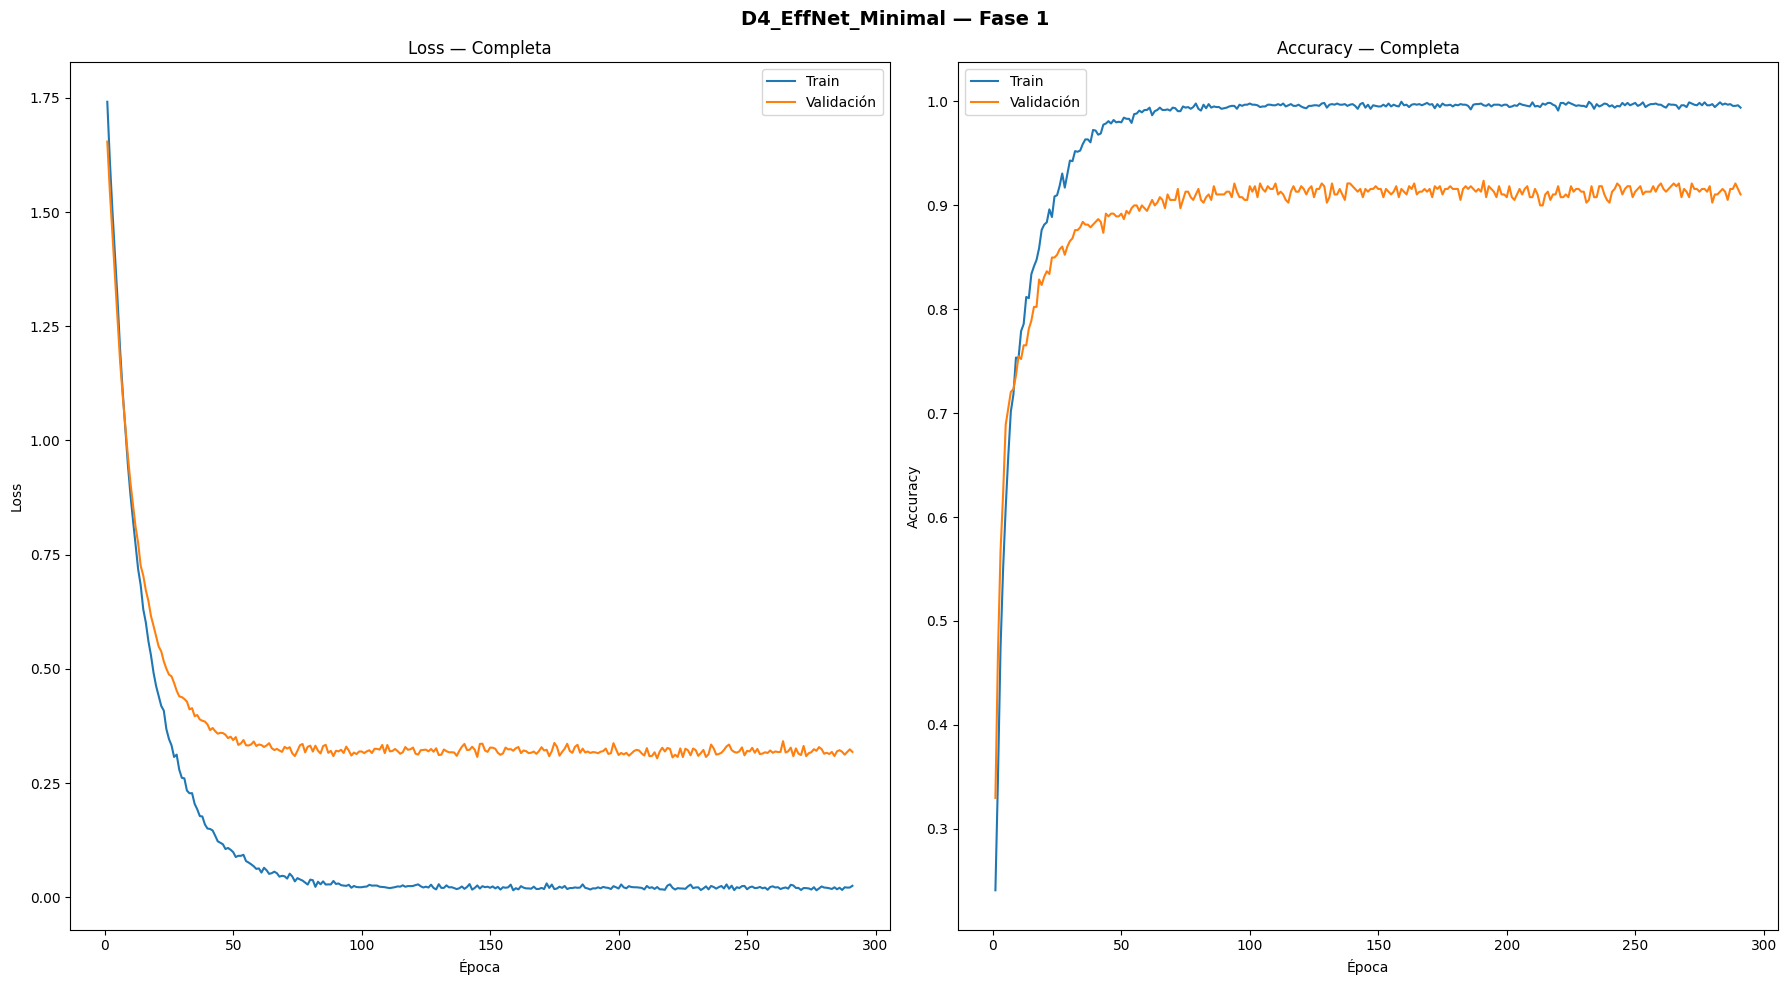

In [7]:
def smooth(values, weight=0.85):
    """Suavizado exponencial (similar a TensorBoard)."""
    smoothed, last = [], values[0]
    for v in values:
        last = last * weight + (1 - weight) * v
        smoothed.append(last)
    return smoothed


def plot_training(history, title='', phase=1):
    loss     = history.history['loss']
    val_loss = history.history['val_loss']
    acc      = history.history['accuracy']
    val_acc  = history.history['val_accuracy']
    epochs   = range(1, len(loss) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(18, 10))
    fig.suptitle(f'{title} — Fase {phase}', fontsize=14, fontweight='bold')

    # ── Fila 1: Loss ─────────────────────────────────────────────────────────
    # 1a) Curva completa
    axes[0].plot(epochs, loss,     label='Train')
    axes[0].plot(epochs, val_loss, label='Validación')
    axes[0].set_title('Loss — Completa')
    axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
    axes[0].legend()

    # ── Fila 2: Accuracy ─────────────────────────────────────────────────────
    axes[1].plot(epochs, acc,     label='Train')
    axes[1].plot(epochs, val_acc, label='Validación')
    axes[1].set_title('Accuracy — Completa')
    axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
    axes[1].legend()


    plt.tight_layout()
    plt.savefig(f'curvas_{MODEL_NAME}_fase{phase}.png', dpi=150)
    plt.show()


plot_training(history_p1, title=MODEL_NAME, phase=1)



---
## 5. Evaluación — Train / Val / Test


In [8]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_split(model, X, y, split_name):
    """Calcula y muestra Accuracy, Precision, Recall y F1-macro."""
    y_pred = np.argmax(model.predict(X, verbose=0), axis=1)
    acc  = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y, y_pred, average='macro', zero_division=0)
    print(f'[{split_name:>5}]  Acc={acc:.4f}  Prec={prec:.4f}  '
          f'Rec={rec:.4f}  F1={f1:.4f}')
    return {'split': split_name, 'acc': acc,
            'prec': prec, 'rec': rec, 'f1': f1, 'y_pred': y_pred}

print('-' * 60)
print(f'Modelo: {MODEL_NAME}')
print('-' * 60)
res_train = evaluate_split(model, X_train, y_train, 'Train')
res_val   = evaluate_split(model, X_val,   y_val,   'Val')
res_test  = evaluate_split(model, X_test,  y_test,  'Test')
print('-' * 60)

------------------------------------------------------------
Modelo: D4_EffNet_Minimal
------------------------------------------------------------
[Train]  Acc=0.9989  Prec=0.9989  Rec=0.9990  F1=0.9990
[  Val]  Acc=0.9235  Prec=0.9147  Rec=0.9153  F1=0.9140


2026-03-29 11:34:02.848367: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-29 11:34:02.930884: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-29 11:34:03.205132: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-29 11:34:03.290725: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


[ Test]  Acc=0.9395  Prec=0.9297  Rec=0.9288  F1=0.9291
------------------------------------------------------------


In [9]:
# ── Número de parámetros (para la tabla del README) ──────────────────────────
total_params     = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])

print(f'Parámetros totales    : {total_params:,}')
print(f'Parámetros entrenables: {trainable_params:,}')

Parámetros totales    : 5,926,998
Parámetros entrenables: 5,866,390


---
## 6. Matriz de confusión


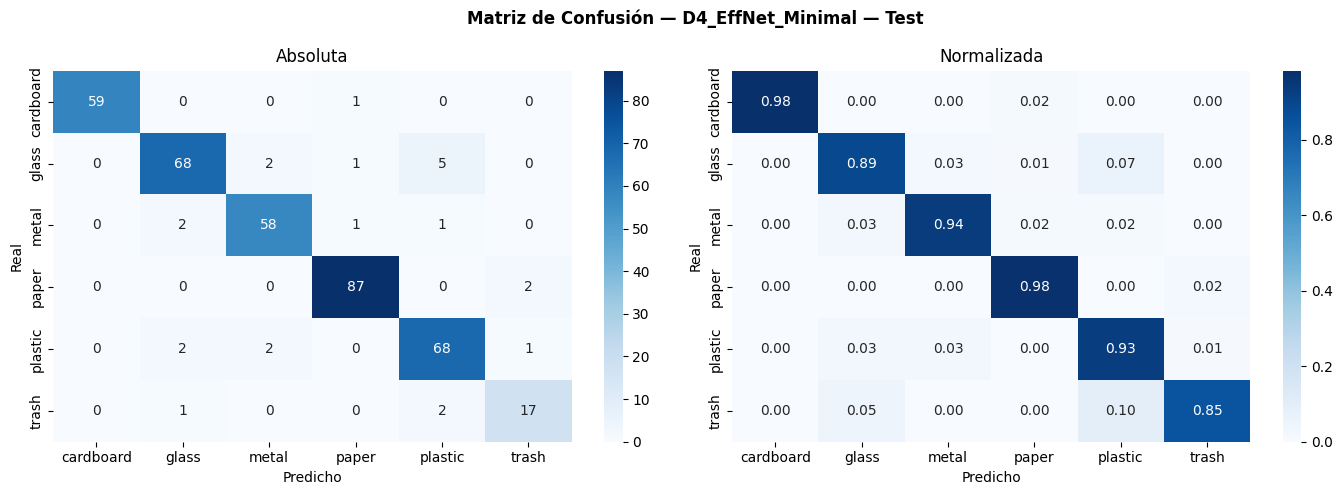

              precision    recall  f1-score   support

   cardboard       1.00      0.98      0.99        60
       glass       0.93      0.89      0.91        76
       metal       0.94      0.94      0.94        62
       paper       0.97      0.98      0.97        89
     plastic       0.89      0.93      0.91        73
       trash       0.85      0.85      0.85        20

    accuracy                           0.94       380
   macro avg       0.93      0.93      0.93       380
weighted avg       0.94      0.94      0.94       380



In [10]:
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred, title='Test'):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Matriz de Confusión — {title}', fontweight='bold')

    for ax, data, fmt, ttl in zip(
        axes,
        [cm, cm_norm],
        ['d', '.2f'],
        ['Absoluta', 'Normalizada']
    ):
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names, ax=ax)
        ax.set_title(ttl)
        ax.set_xlabel('Predicho')
        ax.set_ylabel('Real')

    plt.tight_layout()
    plt.savefig(f'confusion_{MODEL_NAME}.png', dpi=150)
    plt.show()


plot_confusion_matrix(y_test, res_test['y_pred'], title=f'{MODEL_NAME} — Test')
print(classification_report(y_test, res_test['y_pred'],
                             target_names=class_names))


---
## 7. Resumen 


In [12]:
print('─' * 90)
for res in [res_train, res_val, res_test]:
    print(
        f"| **{MODEL_NAME}** | {total_params:,} | {res['split']:>5} "
        f"| {res['acc']:.4f} | {res['prec']:.4f} "
        f"| {res['rec']:.4f} | {res['f1']:.4f} |"
    )
print('─' * 90)

──────────────────────────────────────────────────────────────────────────────────────────
| **D4_EffNet_Minimal** | 5,926,998 | Train | 0.9989 | 0.9989 | 0.9990 | 0.9990 |
| **D4_EffNet_Minimal** | 5,926,998 |   Val | 0.9235 | 0.9147 | 0.9153 | 0.9140 |
| **D4_EffNet_Minimal** | 5,926,998 |  Test | 0.9395 | 0.9297 | 0.9288 | 0.9291 |
──────────────────────────────────────────────────────────────────────────────────────────
